In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
SPLICE_CLASS_NAMES = ["Donor+", "Acceptor+", "Donor-", "Acceptor-"]
BACKGROUND_CLASS = 4
CLASS_LABELS = {0: 'donor +', 1: 'acceptor +', 2: 'donor -', 3: 'acceptor -', 4: 'no splice site'}
CLASS_COLORS  = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

TISSUE_COLORS = {
    'Brain': '#3399cc',
    'Midbrain': '#34b3e6',
    'Cerebellum': '#34ccff',
    'Heart': '#cc0100',
    'Kidney': '#cc9900',
    'Liver': '#339900',
    'Ovary': '#cc329a',
    'Testis': '#ff6600'
}

SPECIES_ORDER = ['human', 'mouse', 'rat'] #, 'rabbit', 'opossum', 'chicken', 'macaque'
TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney", "Liver", "Ovary", "Testis"]

sci_sps = {
    "human": "Homo_sapiens",
    "mouse": "Mus_musculus",
    "rat": "Rattus_norvegicus",
    "rabbit": "Oryctolagus_cuniculus",
    "opossum": "Monodelphis_domestica",
    "chicken": "Gallus_gallus"
}

work_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/"
ann_data_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/"
model = "mini_bce"
model_dir = os.path.join(work_dir, model)

subsets = None # ["intersect", "intersect_protein_coding", "intersect_mazin"]
pred_dir = "preds"

## Evaluation

### Splice site classification

In [3]:
def load_splice_predictions(model_dir, subsets = ["gtf", "usage", "union", "intersect"], species_list = ["human", "mouse", "rat", "rabbit", "opossum"]):
        
    evals = {}
    if subsets is None:
        subsets = ["preds"]
    
    for sub_key in subsets:

        if sub_key == "preds":
            pd_key = "preds"
        else:
            pd_key = "preds_" + sub_key
        
        data_dir = os.path.join(model_dir, pd_key)
        print(f"Loading predictions from {data_dir}")

        for species in species_list:
            if species not in evals:
                evals[species] = {}
            if pd_key not in evals[species]:
                evals[species][pd_key] = {"sites": {}, "auprc": {}, "usage": {}}
            pred_file = os.path.join(data_dir, species, "metrics.json")
            if os.path.exists(pred_file):
                with open(pred_file, "r") as f:
                    metrics = json.load(f)

                sp_metrics = metrics.get(species, {})
                per_class_auprc = sp_metrics.get("per_class_auprc", {}) or {}
                per_class_positives = sp_metrics.get("per_class_n_positives", {}) or {}
                evals[species][pd_key]['sites'] = per_class_positives
                auprc = dict(per_class_auprc)
                auprc["binary"] = sp_metrics.get("binary_auprc", None)
                evals[species][pd_key]['auprc'] = auprc
                overall_cor = sp_metrics.get("usage_by_head", {}).get("same_species", None)
                tissue_cor = sp_metrics.get("per_tissue_by_head", {}).get("same_species", None)
                all_cors = {
                    "overall": overall_cor,
                    "tissue": tissue_cor
                }
                evals[species][pd_key]['usage'] = all_cors
            else:
                print(f"Predictions for {species} in {pd_key} are missing.")

    return evals

#### Evaluate model predictions

In [4]:
evals = load_splice_predictions(model_dir, subsets=subsets, species_list=SPECIES_ORDER)
evals['human']

Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce/preds


{'preds': {'sites': {'Donor+': 2073,
   'Acceptor+': 2080,
   'Donor-': 2150,
   'Acceptor-': 2130},
  'auprc': {'Donor+': 0.6895563077295908,
   'Acceptor+': 0.677007770073004,
   'Donor-': 0.6989404203630744,
   'Acceptor-': 0.6983651139399413,
   'binary': 0.6858043782966148},
  'usage': {'overall': None, 'tissue': None}}}

Plot AUPRC per class for each species (rows) and subset of sites (columns).

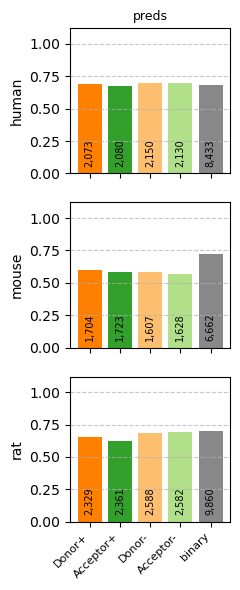

In [5]:
species_list = [s for s in SPECIES_ORDER if s in evals]
if subsets is None:
    subsets_list = ["preds"]
else:
    subsets_list = [s for s in subsets if any(evals[sp].get(s) is not None for sp in species_list)]
n_species = len(species_list)
n_classes = len(SPLICE_CLASS_NAMES) + 1  # +1 for binary
n_preds = len(subsets_list)
import numpy as np

# Add site-count annotations automatically before saving/showing the figure
def _annotate_site_counts(fig):
    if fig is None:
        return

    axs = np.array(fig.axes, dtype=object).reshape(n_species, n_preds)
    keys = SPLICE_CLASS_NAMES + ["binary"]

    for row, sp in enumerate(species_list):
        for col, pd_key in enumerate(subsets_list):
            ax = axs[row, col]

            # Avoid duplicate labels if both savefig() and show() are called
            if getattr(ax, "_site_labels_added", False):
                continue

            site_map = evals.get(sp, {}).get(pd_key, {}).get("sites", {}) or {}
            class_counts = [site_map.get(k, np.nan) for k in SPLICE_CLASS_NAMES]
            binary_count = np.nansum(class_counts) if len(class_counts) else np.nan
            counts = class_counts + [binary_count]

            # Bars in this axis correspond to keys order
            bars = ax.patches[:len(keys)]
            for bar, n in zip(bars, counts):
                if np.isfinite(n):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        0.05,
                        f"{int(n):,}",
                        ha="center",
                        va="bottom",
                        fontsize=7,
                        rotation=90
                    )

            ax.set_ylim(0, 1.12)
            ax._site_labels_added = True


# Patch savefig/show so labels are present both on disk and on-screen
if not hasattr(plt, "_orig_savefig"):
    plt._orig_savefig = plt.savefig
if not hasattr(plt, "_orig_show"):
    plt._orig_show = plt.show

def _savefig_with_site_labels(*args, **kwargs):
    _annotate_site_counts(plt.gcf())
    return plt._orig_savefig(*args, **kwargs)

def _show_with_site_labels(*args, **kwargs):
    _annotate_site_counts(plt.gcf())
    return plt._orig_show(*args, **kwargs)

plt.savefig = _savefig_with_site_labels
plt.show = _show_with_site_labels

fig, axes = plt.subplots(n_species, n_preds, figsize=(n_preds * 2.5, n_species * 2), sharey='row', squeeze=False, sharex=True)

for row, sp in enumerate(species_list):
    for col, pd_key in enumerate(subsets_list):
        ax = axes[row, col]
        sp_data = evals.get(sp, {})
        auprc_data = sp_data.get(pd_key, None).get('auprc', None) if sp_data else None
        if auprc_data is not None:
            keys = SPLICE_CLASS_NAMES + ['binary']
            values = [v if v is not None else np.nan for v in (auprc_data.get(k) for k in keys)]
            colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ['#888888']
            bars = ax.bar(keys, values, color=colors)
            ax.set_ylim(0, 1)
            ax.set_xticks(range(len(keys)))
            ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
        if row == 0:
            ax.set_title(f'{pd_key}' if pd_key else '', fontsize=9)
        if col == 0:
            ax.set_ylabel(sp, fontsize=10)

plt.tight_layout()

# Save plot
plt.savefig(os.path.join(work_dir, model, "prediction_splice_site_auprc_by_subsets.png"), dpi=300)
plt.show()

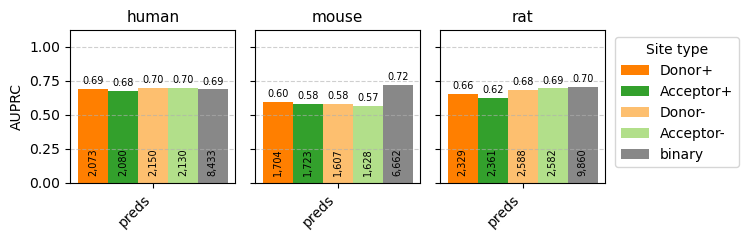

In [6]:
class_keys = SPLICE_CLASS_NAMES + ["binary"]
species_plot = [s for s in SPECIES_ORDER if s in evals]
if subsets is None:
    subset_plot = ["preds"]
else:
    subset_keys = ["preds_" + s for s in subsets]
    subset_plot = [s for s in subset_keys if any(evals[sp].get(s) is not None for sp in species_plot)]
annot_bars = True

fig, axes = plt.subplots(
    1, len(species_plot),
    figsize=(len(species_plot) * 2.5, 2.5),
    sharey=True,
    squeeze=False
)

axes = axes[0]

x_subset = np.arange(len(subset_plot))
bar_width = 0.9 / max(len(class_keys), 1)
class_colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ["#888888"]

for ax, sp in zip(axes, species_plot):
    for j, class_key in enumerate(class_keys):
        values = []
        counts = []

        for subset in subset_plot:
            subset_data = evals.get(sp, {}).get(subset, {})
            auprc_map = subset_data.get("auprc", {}) if subset_data is not None else {}
            site_map = subset_data.get("sites", {}) if subset_data is not None else {}

            values.append(auprc_map.get(class_key, np.nan))

            if class_key == "binary":
                cls_counts = [site_map.get(k, np.nan) for k in SPLICE_CLASS_NAMES]
                n_sites = np.nansum(cls_counts) if len(cls_counts) else np.nan
            else:
                n_sites = site_map.get(class_key, np.nan)
            counts.append(n_sites)

        offsets = x_subset + (j - (len(class_keys) - 1) / 2) * bar_width
        bars = ax.bar(offsets, values, width=bar_width, color=class_colors[j], label=class_key)

        if annot_bars:
            for bar, n, v in zip(bars, counts, values):
                if np.isfinite(v):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        min(v + 0.02, 1.08),
                        f"{v:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=7
                    )

    ax.set_title(sp, fontsize=11)
    ax.set_xticks(x_subset)
    ax.set_xticklabels(subset_plot, rotation=45, ha="right")
    ax.set_ylim(0, 1.12)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("AUPRC")
axes[-1].legend(title="Site type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_auprc_by_subset_grouped.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Compare all models predictions

Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce_wu10/preds
Predictions for rabbit in preds are missing.
Predictions for opossum in preds are missing.
Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce_delta/preds
Predictions for rabbit in preds are missing.
Predictions for opossum in preds are missing.
Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_delta/preds
Predictions for rabbit in preds are missing.
Predictions for opossum in preds are missing.
Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_observed_bce/preds
Predictions for rabbit in preds are missing.
Predictions for opossum in preds are missing.
Loading predictions from /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_observed_bce_wu10/preds
Predictions for rabbit in preds are missing.
Predictions for opossum in preds are missing.
Loading predictions from

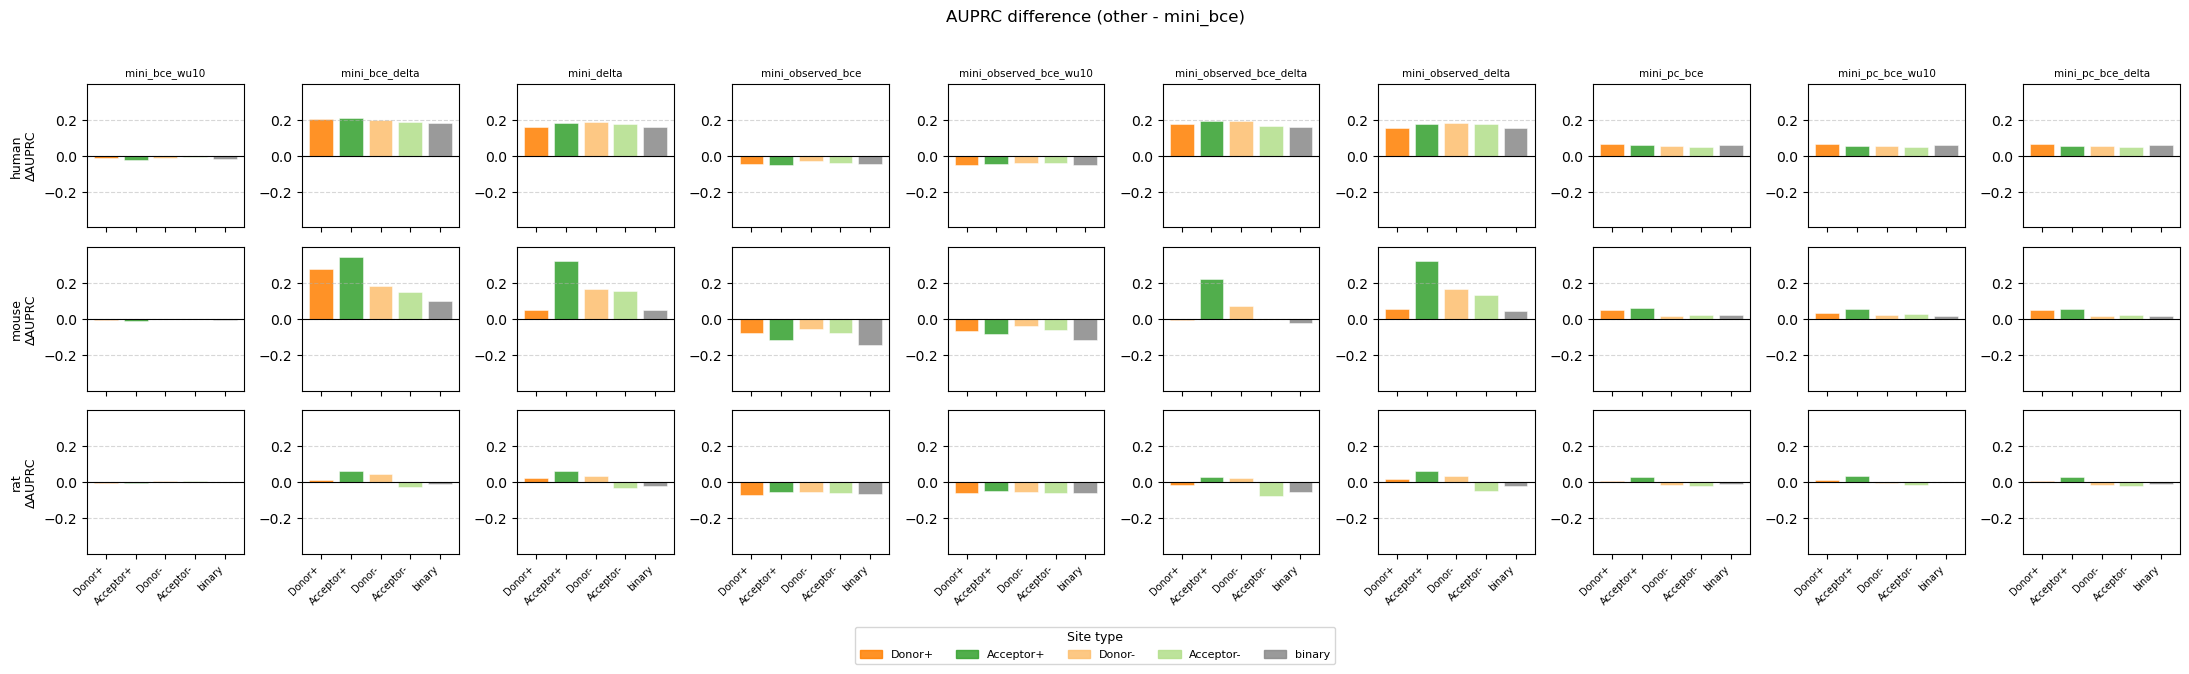

In [7]:
models_to_compare = [
    "mini_bce", "mini_bce_wu10", "mini_bce_delta", "mini_delta",
    "mini_observed_bce", "mini_observed_bce_wu10", "mini_observed_bce_delta", "mini_observed_delta",
    "mini_pc_bce", "mini_pc_bce_wu10", "mini_pc_bce_delta"
]
pov_model = model
pov_first = False

evals_2_dict = {}
for model_ in models_to_compare:
    if model_ == pov_model:
        continue
    model_dir_ = os.path.join(work_dir, model_)
    evals_ = load_splice_predictions(model_dir_, subsets)
    evals_2_dict[model_] = evals_

class_keys = SPLICE_CLASS_NAMES + ["binary"]
model_2_names = list(evals_2_dict.keys())
n_models2 = len(model_2_names)

species_plot = [s for s in SPECIES_ORDER
                if s in evals and any(s in ev for ev in evals_2_dict.values())]
if subsets is None:
    subset_plot = ["preds"]
else:
    subset_plot = [s for s in subsets
                   if any(s in evals.get(sp, {}) for sp in species_plot)]

# Collect all deltas for symmetric y-limit
all_deltas = []
for m2_name, evals_2 in evals_2_dict.items():
    for sp in species_plot:
        for subset in subset_plot:
            a1 = evals.get(sp, {}).get(subset, {}).get("auprc", {})
            a2 = evals_2.get(sp, {}).get(subset, {}).get("auprc", {})
            for k in class_keys:
                v1, v2 = a1.get(k, np.nan), a2.get(k, np.nan)
                if np.isfinite(v1) and np.isfinite(v2):
                    all_deltas.append(v1 - v2 if pov_first else v2 - v1)
ylim = max(0.02, np.nanmax(np.abs(all_deltas)) * 1.15) if all_deltas else 0.05
ylim_min, ylim_max = -ylim, ylim

# Fixed limits if desired
# ylim_min, ylim_max = -0.25, 0.25

# Colors per site type
bar_colors = [CLASS_COLORS[i] for i in range(len(SPLICE_CLASS_NAMES))] + ["#888888"]
n_classes = len(class_keys)
bar_width = 0.8 / max(n_classes, 1)
x_bars = np.arange(n_classes)

# Grid: rows = species, columns = model_2 × subsets
n_rows = len(species_plot)
n_cols = n_models2 * len(subset_plot)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 2.2, n_rows * 2),
    sharey=False,
    squeeze=False
)

for r, sp in enumerate(species_plot):
    for col_m, (m2_name, evals_2) in enumerate(evals_2_dict.items()):
        for col_s, subset in enumerate(subset_plot):
            col = col_m * len(subset_plot) + col_s
            ax = axes[r, col]

            a1 = evals.get(sp, {}).get(subset, {}).get("auprc", {})
            a2 = evals_2.get(sp, {}).get(subset, {}).get("auprc", {})

            deltas = []
            for k in class_keys:
                v1, v2 = a1.get(k, np.nan), a2.get(k, np.nan)
                deltas.append((v1 - v2 if pov_first else v2 - v1)
                               if (np.isfinite(v1) and np.isfinite(v2)) else np.nan)

            ax.bar(
                x_bars, deltas,
                width=bar_width * n_classes,  # full-width individual bars
                color=bar_colors,
                alpha=0.85,
                edgecolor="white",
                linewidth=0.4
            )

            ax.axhline(0, color="black", linewidth=0.8)
            ax.set_ylim(ylim_min, ylim_max)
            ax.grid(axis="y", linestyle="--", alpha=0.5)

            ax.set_xticks(x_bars)
            if r == n_rows - 1:
                ax.set_xticklabels(class_keys, rotation=45, ha="right", fontsize=7)
            else:
                ax.set_xticklabels([])

            # Column header: model name (top row only); subset if >1 subsets
            if r == 0:
                title = m2_name if len(subset_plot) == 1 else f"{m2_name}\n{subset}"
                ax.set_title(title, fontsize=7.5, rotation=0)

            # Row label on leftmost column
            if col == 0:
                ax.set_ylabel(f"{sp}\nΔAUPRC", fontsize=9)


# Single legend for site types, below the figure
handles = [
    plt.Rectangle((0, 0), 1, 1, color=bar_colors[i], alpha=0.85, label=class_keys[i])
    for i in range(n_classes)
]
fig.legend(
    handles=handles,
    title="Site type",
    loc="lower center",
    ncol=n_classes,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.08)   # push further down
)

direction = f"{model} - other" if pov_first else f"other - {model}"
plt.suptitle(f"AUPRC difference ({direction})", y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_site_auprc_diff.png"),
    dpi=300, bbox_inches="tight"
)

### Splice site usage

In [8]:
def load_splice_usage_stats(model_dir, ann_data_dir, subsets=None, species_list=["human", "mouse", "rat", "rabbit", "opossum"]):

    sci_sps = {
        "human": "Homo_sapiens",
        "mouse": "Mus_musculus",
        "rat": "Rattus_norvegicus",
        "rabbit": "Oryctolagus_cuniculus",
        "opossum": "Monodelphis_domestica",
        "chicken": "Gallus_gallus"
    }
    
    usage_results = {}

    for sps in species_list:
        usage_results[sps] = {}

        metadata_file = os.path.join(ann_data_dir, sci_sps[sps], "usage.json")
        if not os.path.exists(metadata_file):
            print(f"Metadata missing for {sps}: {metadata_file}")
            continue

        with open(metadata_file) as f:
            metadata = json.load(f)

        idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

        if subsets is None:
            subsets = ["preds"]

        for sub_key in subsets:
            if sub_key == "preds":
                pd_key = "preds"
            else:
                pd_key = "preds_" + sub_key
            
            usage_file = os.path.join(model_dir, f"{pd_key}", sps, f"usage_{sps}.npz")
            if not os.path.exists(usage_file):
                print(f"  Usage file missing: {sps} / {pd_key}")
                usage_results[sps][pd_key] = None
                continue

            data = np.load(usage_file)
            cond_ids = data["stats_cond_ids"]
            n_arr = data["stats_n"]
            sum_p = data["stats_sum_pred"]
            sum_t = data["stats_sum_true"]
            sum_p2 = data["stats_sum_pred2"]
            sum_t2 = data["stats_sum_true2"]
            sum_pt = data["stats_sum_prod"]

            per_condition = {}
            tissue_stats = {}

            for i, cond_idx in enumerate(cond_ids):
                label = idx_to_label.get(int(cond_idx), f"cond_{cond_idx}")
                tissue, timepoint = split_condition_label(label)

                r_cond = pearson_r_from_stats(
                    n_arr[i], sum_p[i], sum_t[i], sum_p2[i], sum_t2[i], sum_pt[i]
                )

                per_condition[label] = {
                    "tissue": tissue,
                    "timepoint": timepoint,
                    "pearson_r": r_cond,
                    "r_squared": r_cond**2 if np.isfinite(r_cond) else float("nan"),
                    "n": int(n_arr[i]),
                }

                if tissue not in tissue_stats:
                    tissue_stats[tissue] = {
                        "n": 0,
                        "sum_p": 0.0,
                        "sum_t": 0.0,
                        "sum_p2": 0.0,
                        "sum_t2": 0.0,
                        "sum_pt": 0.0,
                        "r_per_cond": [],
                        "timepoints": {},
                    }

                ts = tissue_stats[tissue]
                ts["n"] += int(n_arr[i])
                ts["sum_p"] += float(sum_p[i])
                ts["sum_t"] += float(sum_t[i])
                ts["sum_p2"] += float(sum_p2[i])
                ts["sum_t2"] += float(sum_t2[i])
                ts["sum_pt"] += float(sum_pt[i])
                ts["r_per_cond"].append(r_cond)
                ts["timepoints"][str(timepoint)] = per_condition[label]

            per_tissue = {}
            for tissue, ts in sorted(tissue_stats.items()):
                r_pooled = pearson_r_from_stats(
                    ts["n"], ts["sum_p"], ts["sum_t"], ts["sum_p2"], ts["sum_t2"], ts["sum_pt"]
                )
                valid_r = [r for r in ts["r_per_cond"] if np.isfinite(r)]

                per_tissue[tissue] = {
                    "pearson_r": r_pooled,
                    "r_squared": r_pooled**2 if np.isfinite(r_pooled) else float("nan"),
                    "std_pearson_r": float(np.std(valid_r)) if valid_r else float("nan"),
                    "mean_pearson_r": float(np.mean(valid_r)) if valid_r else float("nan"),
                    "n": ts["n"],
                    "n_conditions": len(ts["r_per_cond"]),
                    "timepoints": dict(sorted(ts["timepoints"].items(), key=lambda x: x[0])),
                }

            r_overall = pearson_r_from_stats(
                n_arr.sum(), sum_p.sum(), sum_t.sum(),
                sum_p2.sum(), sum_t2.sum(), sum_pt.sum()
            )

            usage_results[sps][pd_key] = {
                "overall_pearson_r": r_overall,
                "overall_r_squared": r_overall**2 if np.isfinite(r_overall) else float("nan"),
                "per_tissue": per_tissue,
                "per_condition": per_condition,
            }

            tissue_str = ", ".join(
                f"{t}={v['pearson_r']:.3f}" for t, v in per_tissue.items()
            )
            print(f"  {sps} {pd_key}: overall r={r_overall:.3f}  [{tissue_str}]")


    class NumpyEncoder(json.JSONEncoder):
        def default(self, obj):
            if isinstance(obj, np.integer):
                return int(obj)
            if isinstance(obj, np.floating):
                return float(obj)
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            return super().default(obj)


    usage_results_path = os.path.join(model_dir, "prediction_splice_usage_results.json")
    with open(usage_results_path, "w") as f:
        json.dump(usage_results, f, indent=4, cls=NumpyEncoder)

    print(f"\nSaved to {usage_results_path}")

    return usage_results

def pearson_r_from_stats(n, sum_p, sum_t, sum_p2, sum_t2, sum_pt):
    """Compute Pearson r from sufficient statistics."""
    denom = np.sqrt((n * sum_p2 - sum_p**2) * (n * sum_t2 - sum_t**2))
    if denom < 1e-12:
        return float("nan")
    return float((n * sum_pt - sum_p * sum_t) / denom)


def split_condition_label(label):
    """Split 'Tissue_Timepoint' -> (tissue, timepoint)."""
    if "_" in label:
        tissue, timepoint = label.rsplit("_", 1)
        return tissue, timepoint
    return label, None


#### Evaluate model predictions

In [9]:
usage_results = load_splice_usage_stats(model_dir, ann_data_dir, subsets=subsets, species_list=SPECIES_ORDER)

  human preds: overall r=0.667  [Brain=0.625, Cerebellum=0.537, Heart=0.620, Kidney=0.641, Liver=0.615, Midbrain=0.695, Ovary=0.755, Testis=0.711]
  mouse preds: overall r=0.613  [Brain=0.605, Cerebellum=0.590, Heart=0.618, Kidney=0.635, Liver=0.634, Ovary=0.629, Testis=0.573]
  rat preds: overall r=0.548  [Brain=0.560, Cerebellum=0.549, Heart=0.516, Kidney=0.562, Liver=0.545, Ovary=0.544, Testis=0.548]

Saved to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce/prediction_splice_usage_results.json


In [10]:
# human Cerebellum 1-3 and 14-15 are outliers - exclude those timepoints
if subsets is None:
    sb = ["preds"]
else:
    sb = subsets
for pd_key in sb:
    if "human" in usage_results and usage_results['human'][pd_key] is not None:        
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("1", None)
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("2", None)
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("3", None)
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("7", None)
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("14", None)
        usage_results["human"][pd_key]["per_tissue"]["Cerebellum"]["timepoints"].pop("15", None)


Plot usage correlations per species and tissue

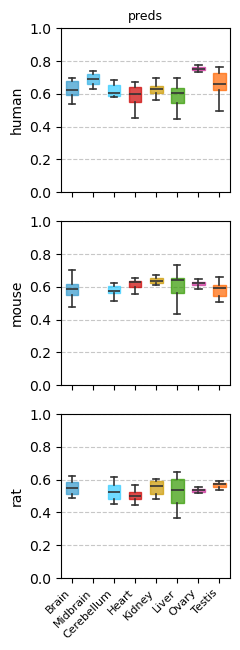

In [12]:
species_list = [s for s in SPECIES_ORDER if s in usage_results]
n_species = len(species_list)
n_subsets = len(sb)

fig, axes = plt.subplots(
    n_species, n_subsets,
    figsize=(n_subsets * 2.5, n_species * 2.2),
    sharey=True, sharex=True
)

if n_species == 1 and n_subsets == 1:
    axes = np.array([[axes]])
elif n_species == 1:
    axes = axes[np.newaxis, :]
elif n_subsets == 1:
    axes = axes[:, np.newaxis]

x = np.arange(len(TISSUE_ORDER))

ymin = 0.0
ymax = 1.0

for row, sp in enumerate(species_list):
    for col, subset in enumerate(sb):
        ax = axes[row, col]
        sp_data = usage_results.get(sp, {})
        usage_data = sp_data.get(subset) if sp_data else None
        tissue_data = usage_data.get("per_tissue", None) if usage_data else None

        if tissue_data:
            box_data = []
            positions = []
            colors = []

            for i, tissue in enumerate(TISSUE_ORDER):
                tp_dict = tissue_data.get(tissue, {}).get("timepoints", {})
                vals = [
                    tp_info.get("pearson_r", np.nan)
                    for tp_info in tp_dict.values()
                    if np.isfinite(tp_info.get("pearson_r", np.nan))
                ]

                if vals:
                    box_data.append(vals)
                    positions.append(i)
                    colors.append(TISSUE_COLORS.get(tissue, "#444444"))

            if box_data:
                bp = ax.boxplot(
                    box_data,
                    positions=positions,
                    widths=0.6,
                    patch_artist=True,
                    showfliers=False
                )

                for patch, color in zip(bp["boxes"], colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                    patch.set_edgecolor(color)

                for element in ["whiskers", "caps", "medians"]:
                    for artist in bp[element]:
                        artist.set_color("#333333")
                        artist.set_linewidth(1.2)

        ax.set_ylim(ymin, ymax)
        ax.set_xlim(-0.5, len(TISSUE_ORDER) - 0.5)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        if row == 0:
            ax.set_title(subset, fontsize=9)
        if col == 0:
            ax.set_ylabel(sp, fontsize=10)

        ax.set_xticks(x)
        if row == n_species - 1:
            ax.set_xticklabels(TISSUE_ORDER, rotation=45, ha="right", fontsize=8)
        else:
            ax.set_xticklabels([])

plt.tight_layout()

fig.savefig(
    os.path.join(work_dir, model, "prediction_splice_usage_correlations_by_subsets.png"),
    dpi=300
)

#### Compare all models predictions

In [13]:
models_to_compare = [
    "mini_bce", "mini_bce_wu10", "mini_bce_delta", "mini_delta",
    "mini_observed_bce", "mini_observed_bce_wu10", "mini_observed_bce_delta", "mini_observed_delta",
    "mini_pc_bce", "mini_pc_bce_wu10", "mini_pc_bce_delta"
]
pov_model = model
pov_first = False  # If True, bars show (pov_model - other), else (other - pov_model)

usage_results_2_dict = {}

for model_ in models_to_compare:
    if model_ == pov_model:
        continue
    model_dir_ = os.path.join(work_dir, model_)
    usage_results_ = load_splice_usage_stats(model_dir_, ann_data_dir, subsets=subsets, species_list=SPECIES_ORDER)
    usage_results_2_dict[model_] = usage_results_


# Apply per-model outlier exclusions
cerebellum_exclude = ["1", "2", "3", "7", "14", "15"]
for m2_name, ur2 in usage_results_2_dict.items():
    for pd_key in sb:
        if "human" in ur2 and ur2["human"].get(pd_key) is not None:
            tp_dict = ur2["human"][pd_key]["per_tissue"].get("Cerebellum", {}).get("timepoints", {})
            for tp in cerebellum_exclude:
                tp_dict.pop(tp, None)


  human preds: overall r=0.675  [Brain=0.635, Cerebellum=0.542, Heart=0.644, Kidney=0.656, Liver=0.641, Midbrain=0.703, Ovary=0.751, Testis=0.713]
  mouse preds: overall r=0.612  [Brain=0.614, Cerebellum=0.611, Heart=0.612, Kidney=0.631, Liver=0.626, Ovary=0.626, Testis=0.559]
  rat preds: overall r=0.561  [Brain=0.576, Cerebellum=0.567, Heart=0.529, Kidney=0.568, Liver=0.558, Ovary=0.558, Testis=0.558]

Saved to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce_wu10/prediction_splice_usage_results.json
  human preds: overall r=0.459  [Brain=0.378, Cerebellum=0.333, Heart=0.109, Kidney=0.152, Liver=0.179, Midbrain=0.401, Ovary=0.547, Testis=0.552]
  mouse preds: overall r=0.226  [Brain=0.266, Cerebellum=0.104, Heart=0.179, Kidney=0.257, Liver=0.279, Ovary=0.294, Testis=0.152]
  rat preds: overall r=0.253  [Brain=0.335, Cerebellum=0.238, Heart=0.275, Kidney=0.359, Liver=0.173, Ovary=0.078, Testis=0.298]

Saved to /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/m

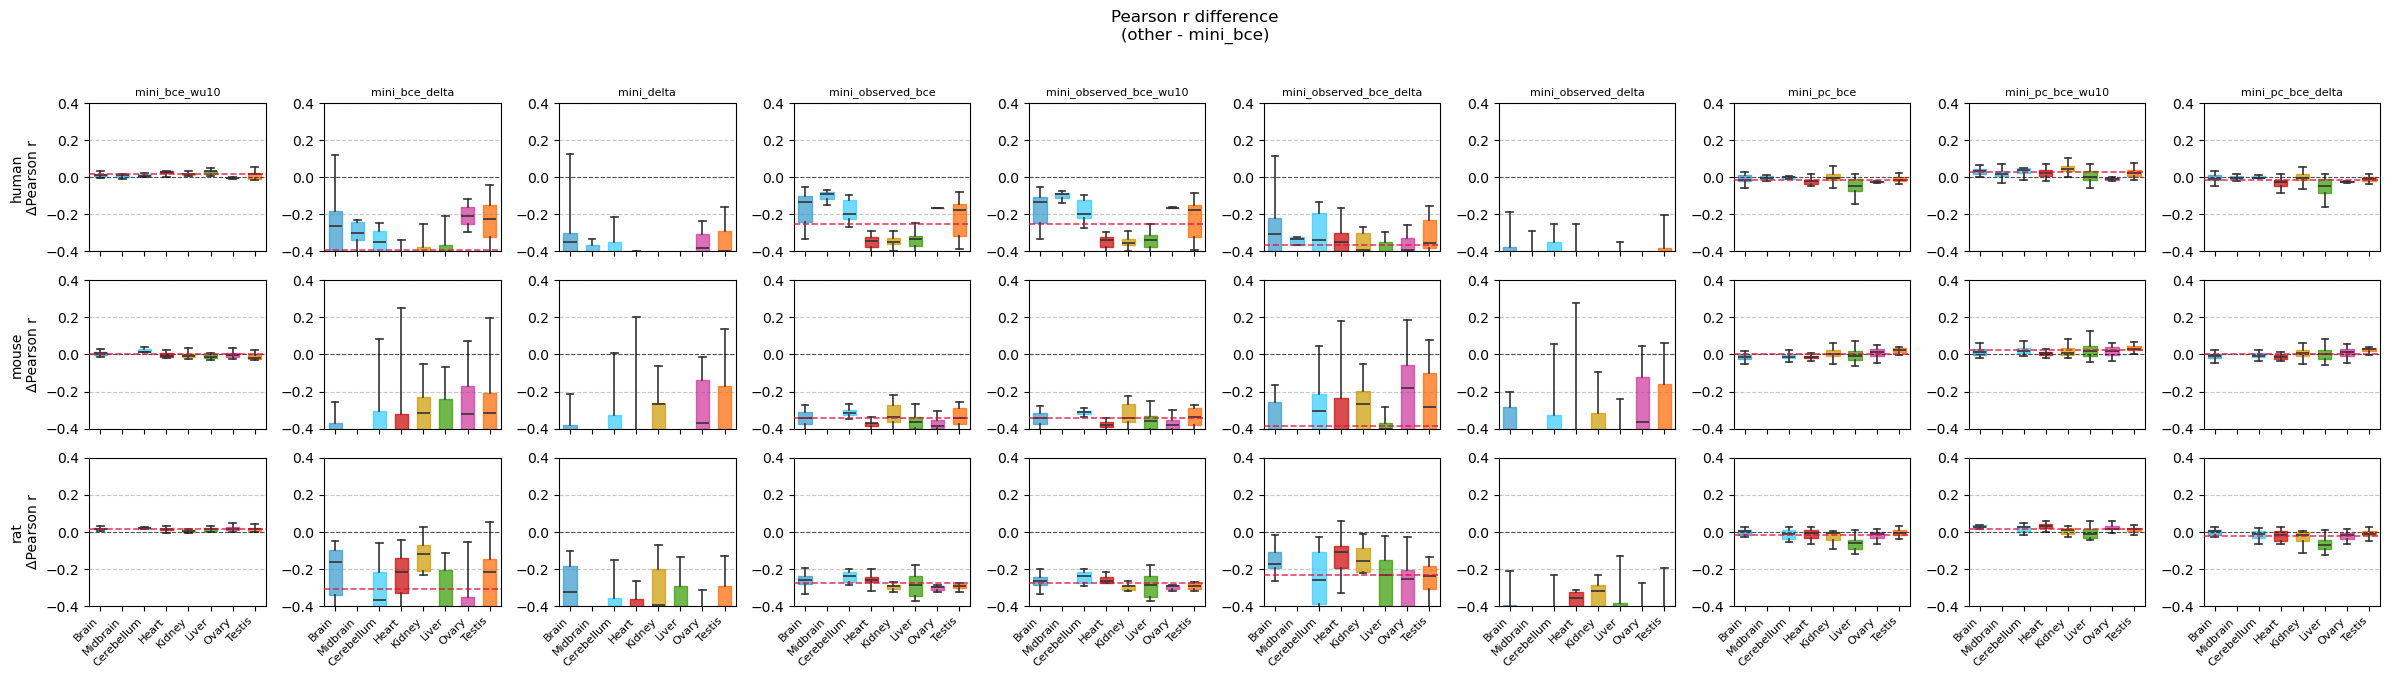

In [14]:
model_2_names = list(usage_results_2_dict.keys())
n_models2 = len(model_2_names)

species_list = [s for s in SPECIES_ORDER
                if s in usage_results or any(s in ur2 for ur2 in usage_results_2_dict.values())]
n_species = len(species_list)
n_subsets = len(sb)

# Collect all diffs for symmetric y-limit
all_diffs = []
for ur2 in usage_results_2_dict.values():
    for sp in species_list:
        for subset in sb:
            td1 = usage_results.get(sp, {}).get(subset, {}).get("per_tissue", None)
            td2 = ur2.get(sp, {}).get(subset, {})
            if td2 is not None:
                td2 = td2.get("per_tissue", None)
            else:
                continue
            if not td1 or not td2:
                continue
            for tissue in TISSUE_ORDER:
                for tp, tp_info_1 in td1.get(tissue, {}).get("timepoints", {}).items():
                    tp_info_2 = td2.get(tissue, {}).get("timepoints", {}).get(tp)
                    if tp_info_2 is None:
                        continue
                    r1 = tp_info_1.get("pearson_r", np.nan)
                    r2 = tp_info_2.get("pearson_r", np.nan)
                    if np.isfinite(r1) and np.isfinite(r2):
                        if pov_first:
                            all_diffs.append(r1 - r2)
                    else:
                        all_diffs.append(r2 - r1)
ylim = max(0.05, np.nanmax(np.abs(all_diffs)) * 1.15) if all_diffs else 0.2
ylim_min, ylim_max = -ylim, ylim

# Alternative: no y limit
ylim_min = None
ylim_max = None

# Alternative: fixed y limit
ylim_min = -0.4
ylim_max = 0.4

# Layout: rows = species, columns = subsets × model_2s
n_cols = n_subsets * n_models2
fig, axes = plt.subplots(
    n_species, n_cols,
    figsize=(n_cols * 2.4, n_species * 2.2),
    sharey=False, sharex=True
)
if n_species == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_species == 1:
    axes = axes[np.newaxis, :]
elif n_cols == 1:
    axes = axes[:, np.newaxis]

x = np.arange(len(TISSUE_ORDER))

for row, sp in enumerate(species_list):
    for col_s, subset in enumerate(sb):
        for col_m, (m2_name, ur2) in enumerate(usage_results_2_dict.items()):
            col = col_s * n_models2 + col_m
            ax = axes[row, col]

            td1 = usage_results.get(sp, {}).get(subset, {}).get("per_tissue", None)
            td2 = ur2.get(sp, {}).get(subset, {})
            if td2 is not None:
                td2 = td2.get("per_tissue", None)

                if td1 and td2:
                    box_data, positions, colors = [], [], []
                    for i, tissue in enumerate(TISSUE_ORDER):
                        tp_dict_1 = td1.get(tissue, {}).get("timepoints", {})
                        tp_dict_2 = td2.get(tissue, {}).get("timepoints", {})
                        diffs = []
                        for tp, tp_info_1 in tp_dict_1.items():
                            tp_info_2 = tp_dict_2.get(tp)
                            if tp_info_2 is None:
                                continue
                            r1 = tp_info_1.get("pearson_r", np.nan)
                            r2 = tp_info_2.get("pearson_r", np.nan)
                            if np.isfinite(r1) and np.isfinite(r2):
                                if pov_first:
                                    diffs.append(r1 - r2)
                                else:
                                    diffs.append(r2 - r1)
                        if diffs:
                            box_data.append(diffs)
                            positions.append(i)
                            colors.append(TISSUE_COLORS.get(tissue, "#444444"))

                    if box_data:
                        bp = ax.boxplot(
                            box_data, positions=positions, widths=0.6,
                            patch_artist=True, showfliers=False
                        )
                        for patch, color in zip(bp["boxes"], colors):
                            patch.set_facecolor(color)
                            patch.set_alpha(0.7)
                            patch.set_edgecolor(color)
                        for element in ["whiskers", "caps", "medians"]:
                            for artist in bp[element]:
                                artist.set_color("#333333")
                                artist.set_linewidth(1.2)

                        # Mean across all tissues/timepoints in this subplot
                        overall_mean = np.nanmean([v for vals in box_data for v in vals])
                        ax.axhline(overall_mean, color="crimson", linewidth=1.2,
                                linestyle="--", alpha=0.8, zorder=3,
                                label=f"mean={overall_mean:+.3f}")
                    
            ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

            if ylim_min is None or ylim_max is None:
                # Compute symmetric limits based on data in this subplot
                local_diffs = []
                for line in ax.get_lines():
                    ydata = line.get_ydata()
                    local_diffs.extend(y for y in ydata if np.isfinite(y))
                if local_diffs:
                    local_max = np.nanmax(np.abs(local_diffs)) * 1.15
                    ylim_local_min, ylim_local_max = -local_max, local_max
                    ax.set_ylim(ylim_local_min, ylim_local_max)
            else:
                ax.set_ylim(ylim_min, ylim_max)
                
            ax.set_xlim(-0.5, len(TISSUE_ORDER) - 0.5)
            ax.grid(axis="y", linestyle="--", alpha=0.7)

            # Column headers: "subset — model_2" on first row
            if row == 0:
                ax.set_title(f"{m2_name}", fontsize=8)
            if col == 0:
                ax.set_ylabel(f"{sp}\nΔPearson r", fontsize=10)

            ax.set_xticks(x)
            if row == n_species - 1:
                ax.set_xticklabels(TISSUE_ORDER, rotation=45, ha="right", fontsize=8)
            else:
                ax.set_xticklabels([])

            # Separator between subset groups
            if col_m == 0 and col > 0:
                ax.spines["left"].set_linewidth(1.8)
                ax.spines["left"].set_color("black")

model_2_label = ", ".join(model_2_names)
if pov_first:
    plt.suptitle(f"Pearson r difference\n({model} - other)", y=1.02, fontsize=12)
else:
    plt.suptitle(f"Pearson r difference\n(other - {model})", y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, f"prediction_splice_usage_correlations_diff.png"),
    dpi=300, bbox_inches="tight"
)

## Predictions

### Splice site classification

Load splice site classification predictions and labels for each species and subset.

In [11]:
%%time
import os
import json

save = False
class_results = {}

if pred_dir != "preds":
    pd_key = "preds_" + pred_dir
else:
    pd_key = "preds"
data_dir = os.path.join(work_dir, model, f"{pd_key}")
print(f"Data directory for predictions: {data_dir}")

class_keys = SPLICE_CLASS_NAMES + ["binary"]

for species in ["human", "mouse", "rat", "rabbit", "opossum"]: 

    if species not in class_results:
        
        class_results[species] = {}
        
        # Load predictions
        pred_file = os.path.join(data_dir, species, f"predictions_{species}.npz")
        if os.path.exists(pred_file):
            preds = np.load(pred_file)
        else:
            print(f"Predictions for {species} in {pd_key} are missing ({pred_file}).")
            continue        
        print(f"Loaded predictions for {species}")

        # Load genomic intervals for each prediction
        bed_file = os.path.join(data_dir, species, f"sampled_windows_{species}.bed")
        if os.path.exists(bed_file):
            bed_df = pd.read_csv(bed_file, sep="\t", index_col=False, header=None, names=["chrom", "start", "end", "strand", "mask_rel_start", "mask_rel_end"])
            bed_df['mask_start'] = bed_df['start'] + bed_df['mask_rel_start']
            bed_df['mask_end'] = bed_df['start'] + bed_df['mask_rel_end']
        else:
            print(f"BED file for {species} in {pd_key} is missing.")
            continue
        
        # Build a dataframe with one row per position in each chrom:mask_start-mask_end interval
        true_cls = preds['cls_labels']
        cls_probs = preds['cls_probs']
        rows = []
        for _, row in bed_df.iterrows():
            for pos in range(row['mask_start'], row['mask_end']):
                rows.append({'chrom': row['chrom'], 'position': pos})

        positions_df = pd.DataFrame(rows)

        # Check that positions_df has the same number of rows as the total number of elements in preds['cls_probs']
        assert len(positions_df) == true_cls.shape[0], f"Mismatch between positions dataframe ({len(positions_df)}) and predictions array length ({preds['cls_probs'].shape[0]})"

        # Add true labels
        positions_df['class_label'] = true_cls

        # Add predicted probabilities for each class
        for i, class_name in enumerate(class_keys):
            positions_df[f'prob_{i}'] = cls_probs[:, i]

        # Add predicted class based on highest probability
        positions_df['predicted_class_label'] = positions_df[[f'prob_{i}' for i in range(len(class_keys))]].idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

        print(f"Collected {positions_df.shape[0]} positions for {species} into dataframe")

        # Save to disk
        if save:
            pq_file = os.path.join(work_dir, model, pd_key, species, f"predictions_{species}.parquet")
            positions_df.to_parquet(pq_file, index=False)
            print(f"Saved predictions for {species} to parquet: {pq_file}")

        class_results[species] = positions_df

class_results 

Data directory for predictions: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce/preds
Loaded predictions for human
BED file for human in preds is missing.
Loaded predictions for mouse
BED file for mouse in preds is missing.
Loaded predictions for rat
BED file for rat in preds is missing.
Predictions for rabbit in preds are missing (/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce/preds/rabbit/predictions_rabbit.npz).
Predictions for opossum in preds are missing (/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/mini_bce/preds/opossum/predictions_opossum.npz).
CPU times: user 2.74 ms, sys: 150 μs, total: 2.89 ms
Wall time: 68.7 ms


{'human': {}, 'mouse': {}, 'rat': {}, 'rabbit': {}, 'opossum': {}}

In [ ]:
%%time
# Combine all species into one dataframe for analysis
combined_df = pd.concat(class_results.values(), keys=class_results.keys(), names=['species', 'row_id']).reset_index(level='row_id', drop=True).reset_index()
combined_df

In [ ]:
if save:
    pq_file = os.path.join(work_dir, model, f"preds_{pd_key}", f"predictions.parquet")
    combined_df.to_parquet(pq_file, index=False)
    print(f"Saved predictions to parquet: {pq_file}")

### Splice usage predictions

Load splice usage predictions and condition labels for each species and subset.

In [13]:
%%time
usage_results = {}

for sps in SPECIES_ORDER:
    usage_results[sps] = {}

    # Load condition metadata: maps condition index -> "Tissue_Timepoint" label
    metadata_file = os.path.join(ann_data_dir, sci_sps[sps], "usage.json")
    if not os.path.exists(metadata_file):
        print(f"Metadata missing for {sps}: {metadata_file}")
        continue
    with open(metadata_file) as f:
        metadata = json.load(f)
    idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

    if pred_dir != "preds":
        pd_key = "preds_" + pred_dir
    else:
        pd_key = "preds"
    usage_file = os.path.join(work_dir, model, f"{pd_key}", sps, f"usage_{sps}.npz")
    if not os.path.exists(usage_file):
        print(f"  Usage file missing: {sps} / {pd_key}")
        usage_results[sps][pd_key] = None
        continue

    data = np.load(usage_file)
    chr_pos    = data["chr_pos"]
    cond_ids   = data["cond_ids"]
    trues      = data["true"]
    preds      = data["pred"]

    # Split condition labels into Tissue and Timepoint
    tissues = []        
    timepoints = []
    for cond_id in cond_ids:
        tissue, timepoint = idx_to_label[cond_id].split("_")
        tissues.append(tissue)
        timepoints.append(timepoint)

    usage_results[sps] = {
        "chr_pos": chr_pos,
        "cond_ids": cond_ids,
        "tissues": tissues,
        "timepoints": timepoints,
        "trues": trues,
        "preds": preds,
        "idx_to_label": idx_to_label
    }

  Usage file missing: rat / preds
CPU times: user 459 ms, sys: 40.5 ms, total: 499 ms
Wall time: 559 ms


#### Calculate trajectory correlations

In [53]:
# Collect usage observations for all available species
usage_df_by_species = {}
missing_species = []

for sp in SPECIES_ORDER:
    sp_data = usage_results.get(sp)

    # keep only species with direct arrays loaded in usage_results
    if not isinstance(sp_data, dict) or not {"chr_pos", "trues", "preds", "cond_ids"}.issubset(sp_data.keys()):
        missing_species.append(sp)
        continue

    usage_df_by_species[sp] = pd.DataFrame({
        "species": sp,
        "chr_pos": np.asarray(sp_data["chr_pos"]).astype(str),
        "true_usage": np.asarray(sp_data["trues"], dtype=float),
        "pred_usage": np.asarray(sp_data["preds"], dtype=float),
        "cond_idx": np.asarray(sp_data["cond_ids"], dtype=int),
        'tissue': np.asarray(sp_data["tissues"], dtype=str),
        'timepoint': np.asarray(sp_data["timepoints"], dtype=str),
    })

if missing_species:
    print(f"Skipped species with missing usage arrays: {missing_species}")

usage_df_all = pd.concat(usage_df_by_species.values(), ignore_index=True)
print(f"Collected {len(usage_df_all):,} rows from {len(usage_df_by_species)} species.")
usage_df_all

Collected 183,697 rows from 3 species.


,species,chr_pos,true_usage,pred_usage,cond_idx,tissue,timepoint
0,human,1:1535506,0.0,0.217427,0,Brain,1
1,human,1:1535588,0.0,0.189056,0,Brain,1
2,human,1:1535796,0.0,0.194543,0,Brain,1
3,human,1:1539683,0.0,0.215289,0,Brain,1
4,human,1:1539789,0.0,0.232782,0,Brain,1
...,...,...,...,...,...,...,...
183692,rat,1:75675786,0.0,0.342076,89,Testis,9
183693,rat,1:75675879,0.0,0.453610,89,Testis,9
183694,rat,1:75676463,0.0,0.325824,89,Testis,9
183695,rat,1:75676605,0.0,0.364323,89,Testis,9


In [54]:
def _pearson_safe(g):
    x = g["true_usage"].to_numpy(dtype=float)
    y = g["pred_usage"].to_numpy(dtype=float)
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def _mean_safe(s):
    arr = s.to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) == 0:
        return np.nan
    return np.mean(arr)

site_corr_all = (
    usage_df_all.groupby(["species", "chr_pos", "tissue"], as_index=False)
    .apply(lambda g: pd.Series({
        "pearson_r": _pearson_safe(g),
        "mae": np.sqrt(np.mean((g["true_usage"] - g["pred_usage"]) ** 2)),
        "cosine": (
            np.dot(g["true_usage"], g["pred_usage"]) /
            (np.linalg.norm(g["true_usage"]) * np.linalg.norm(g["pred_usage"]))
            if np.linalg.norm(g["true_usage"]) > 0 and np.linalg.norm(g["pred_usage"]) > 0
            else np.nan
        ),
        "n_obs_usage": int(g.loc[g["true_usage"] > 0, "cond_idx"].nunique()),
        "mean_obs_usage": _mean_safe(g.loc[g["true_usage"] > 0, "true_usage"]),
        "mean_true_usage": _mean_safe(g["true_usage"]),
        "mean_pred_usage": _mean_safe(g["pred_usage"]),
        "min_obs_usage": g.loc[g["true_usage"] > 0, "true_usage"].min(),
        "min_true_usage": _mean_safe(g["true_usage"]),
        "max_obs_usage": g["true_usage"].max(),
    }))
    .reset_index(drop=True)
    .sort_values(["species", "pearson_r"], ascending=[True, False])
    .reset_index(drop=True)
)

# How many sites have no observations of true usage > 0 i.e. min_obs is NaN?
n_no_obs = site_corr_all["min_obs_usage"].isna().sum()
print(f"Number of sites with no observations of true usage > 0: {n_no_obs} / {len(site_corr_all)} ({n_no_obs / len(site_corr_all):.2%})")

# Remove sites with no observations of true usage > 0
site_corr_all = site_corr_all[~site_corr_all["min_obs_usage"].isna()].reset_index(drop=True)
site_corr_all

Number of sites with no observations of true usage > 0: 5835 / 14574 (40.04%)


/tmp/ipykernel_1797715/1492913582.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,species,chr_pos,tissue,pearson_r,mae,cosine,n_obs_usage,mean_obs_usage,mean_true_usage,mean_pred_usage,min_obs_usage,min_true_usage,max_obs_usage
0,human,1:10211737,Ovary,1.000000,0.076848,0.898140,2.0,0.021500,0.021500,0.098343,0.007,0.021500,0.036
1,human,1:10230996,Ovary,1.000000,0.128669,0.999544,2.0,0.009000,0.009000,0.129683,0.006,0.009000,0.012
2,human,1:10232249,Ovary,1.000000,0.762208,0.958115,2.0,0.978000,0.978000,0.218466,0.976,0.978000,0.980
3,human,1:10232433,Ovary,1.000000,0.664671,0.998374,2.0,0.973500,0.973500,0.308989,0.969,0.973500,0.978
4,human,1:10248862,Ovary,1.000000,0.071403,0.832230,1.0,0.061000,0.030500,0.101166,0.061,0.030500,0.061
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8734,rat,1:33719715,Liver,-0.714262,0.761071,0.906179,13.0,0.972846,0.972846,0.220056,0.923,0.972846,0.993
8735,rat,1:54440679,Kidney,-0.735627,0.652313,0.981283,11.0,0.947455,0.947455,0.299980,0.851,0.947455,0.971
8736,rat,1:32996397,Heart,-0.793015,0.771106,0.884494,14.0,0.975357,0.975357,0.213470,0.947,0.975357,0.991
8737,rat,1:63021787,Heart,-0.806063,0.757514,0.884646,14.0,0.988500,0.988500,0.243085,0.955,0.988500,1.000


#### Trajectories across all sites

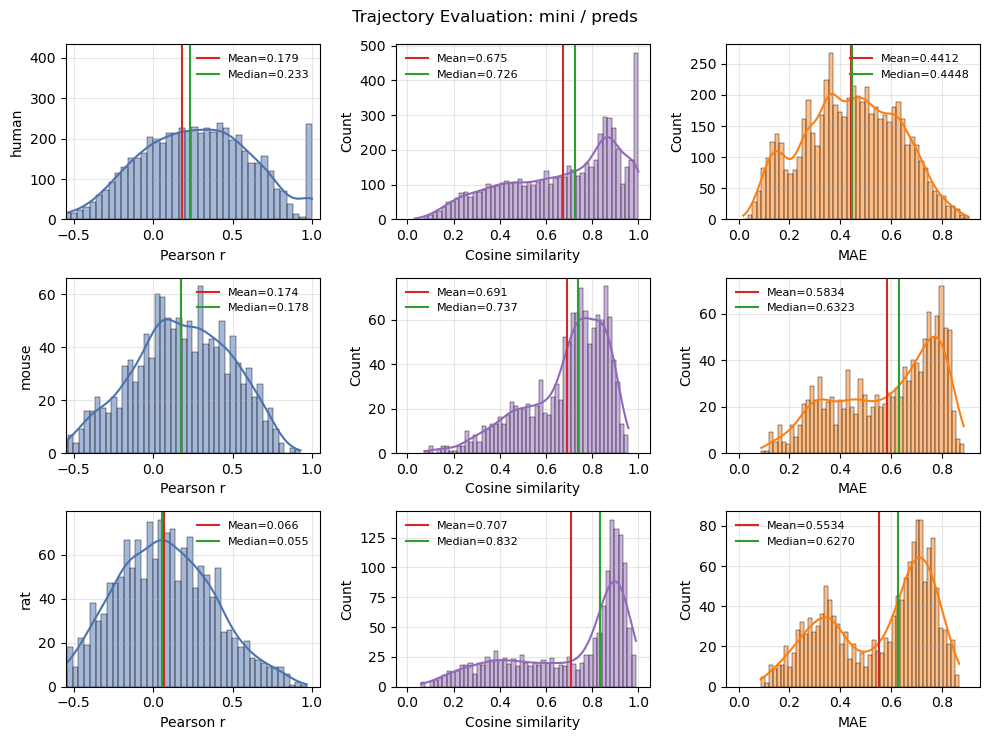

In [55]:
species_list = sorted(site_corr_all['species'].unique())
n_species = len(species_list)

fig, axes = plt.subplots(
    n_species, 3,
    figsize=(10, n_species * 2.5),
    sharey=False
)

if n_species == 1:
    axes = axes.reshape(1, -1)

for row, species in enumerate(species_list):
    sp_data = site_corr_all[site_corr_all['species'] == species].copy()
    
    # 1) Pearson r distribution
    pearson_data = sp_data["pearson_r"].dropna()
    mean_r = pearson_data.mean()
    median_r = pearson_data.median()
    sns.histplot(pearson_data, bins=50, kde=True, color="#4C72B0", ax=axes[row, 0])
    axes[row, 0].axvline(mean_r, color="#d62728", linewidth=1.5, linestyle="-", label=f"Mean={mean_r:.3f}")
    axes[row, 0].axvline(median_r, color="#2ca02c", linewidth=1.5, linestyle="-", label=f"Median={median_r:.3f}")
    axes[row, 0].set_xlim(-0.55, 1.05)
    axes[row, 0].set_ylabel(species, fontsize=10)
    axes[row, 0].set_xlabel("Pearson r")
    axes[row, 0].legend(frameon=False, fontsize=8)
    axes[row, 0].grid(alpha=0.3)

    # 2) Cosine similarity distribution
    cos_data = sp_data["cosine"].dropna()
    mean_cos = cos_data.mean()
    median_cos = cos_data.median()
    sns.histplot(cos_data, bins=50, kde=True, color="#9467bd", ax=axes[row, 1])
    axes[row, 1].axvline(mean_cos, color="#d62728", linewidth=1.5, linestyle="-", label=f"Mean={mean_cos:.3f}")
    axes[row, 1].axvline(median_cos, color="#2ca02c", linewidth=1.5, linestyle="-", label=f"Median={median_cos:.3f}")
    axes[row, 1].set_xlim(-0.05, 1.05)
    axes[row, 1].set_xlabel("Cosine similarity")
    axes[row, 1].legend(frameon=False, fontsize=8)
    axes[row, 1].grid(alpha=0.3)

    # 3) MAE distribution
    mae_data = sp_data["mae"].dropna()
    mean_mae = mae_data.mean()
    median_mae = mae_data.median()
    sns.histplot(mae_data, bins=50, kde=True, color="#ff7f0e", ax=axes[row, 2])
    axes[row, 2].axvline(mean_mae, color="#d62728", linewidth=1.5, linestyle="-", label=f"Mean={mean_mae:.4f}")
    axes[row, 2].axvline(median_mae, color="#2ca02c", linewidth=1.5, linestyle="-", label=f"Median={median_mae:.4f}")
    axes[row, 2].set_xlim(-0.05, 0.95)
    axes[row, 2].set_xlabel("MAE")
    axes[row, 2].legend(frameon=False, fontsize=8)
    axes[row, 2].grid(alpha=0.3)

plt.suptitle(f"Trajectory Evaluation: {model} / {pd_key}", fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(work_dir, model, f"{pd_key}", "trajectory_correlation_distributions.png"), dpi=300)

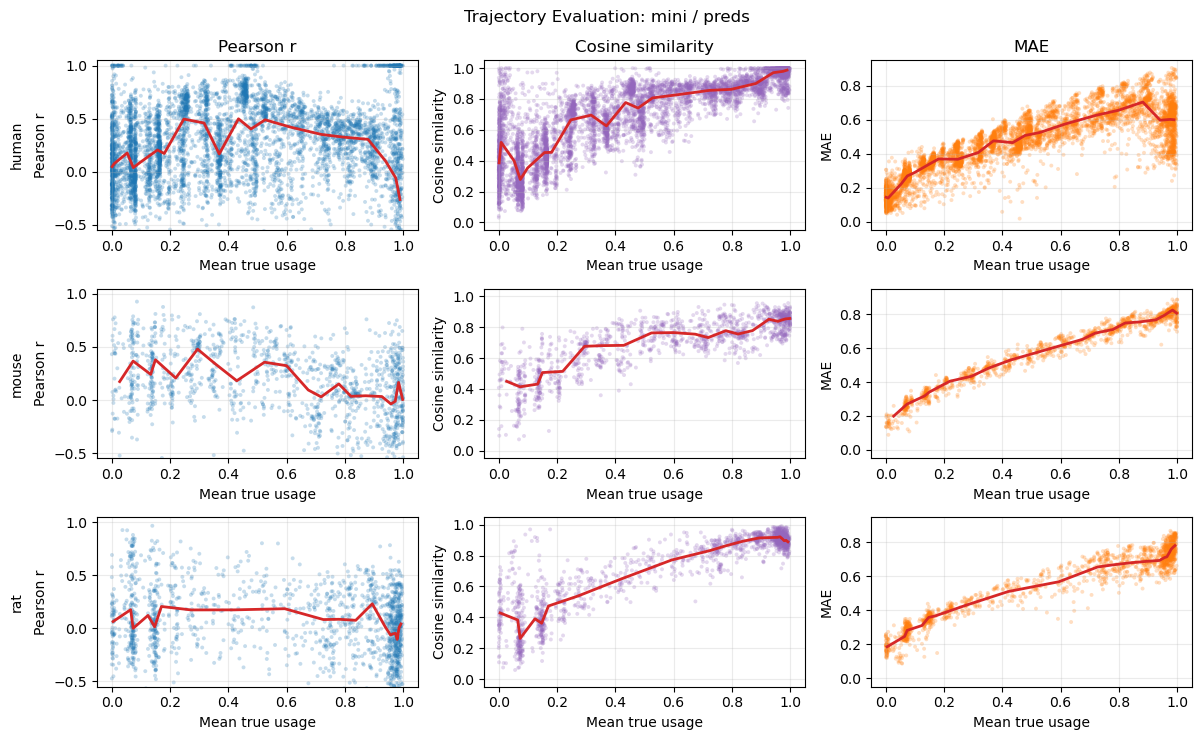

In [56]:
# Scatterplots: mean usage vs per-site Pearson r, cosine similarity, and MAE (all species)
n_bins = 20

species_plot = sorted(site_corr_all["species"].dropna().unique())
metric_specs = [
    ("pearson_r", "Pearson r", "#1f77b4", (-0.55, 1.05)),
    ("cosine", "Cosine similarity", "#9467bd", (-0.05, 1.05)),
    ("mae", "MAE", "#ff7f0e", (-0.05, 0.95)),
]

fig, axes = plt.subplots(
    len(species_plot), 3,
    figsize=(12, max(2.5 * len(species_plot), 3.0)),
    sharex=True,
    squeeze=False
)

for r, sp in enumerate(species_plot):
    sp_df = site_corr_all[site_corr_all["species"] == sp].copy()

    for c, (metric_key, metric_label, color, ylim) in enumerate(metric_specs):
        ax = axes[r, c]
        dfm = sp_df[np.isfinite(sp_df["mean_true_usage"]) & np.isfinite(sp_df[metric_key])].copy()

        ax.scatter(
            dfm["mean_true_usage"],
            dfm[metric_key],
            s=8, alpha=0.25, color=color, edgecolors="none"
        )

        if len(dfm) > 1 and dfm["mean_true_usage"].nunique() > 1:
            q_use = min(n_bins, dfm["mean_true_usage"].nunique())
            if q_use >= 2:
                dfm["usage_bin"] = pd.qcut(dfm["mean_true_usage"], q=q_use, duplicates="drop")
                trend = (
                    dfm.groupby("usage_bin", observed=False)
                    .agg(x=("mean_true_usage", "median"), y=(metric_key, "median"))
                    .dropna()
                )
                if len(trend) > 0:
                    ax.plot(trend["x"], trend["y"], color="#d62728", linewidth=2)

        ax.set_ylim(*ylim)
        ax.grid(alpha=0.25)

        # Show axis labels on every subplot
        ax.set_xlabel("Mean true usage")
        ax.set_ylabel(metric_label)

        # Show tick labels on every subplot despite shared axes
        ax.tick_params(labelbottom=True, labelleft=True)

        if r == 0:
            ax.set_title(metric_label)
        if c == 0:
            ax.text(
                -0.25, 0.5, sp,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center", fontsize=10
            )

plt.suptitle(f"Trajectory Evaluation: {model} / {pd_key}", fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(work_dir, model, f"{pd_key}", "trajectory_correlation_vs_mean_true_usage.png"), dpi=300)


Correlation is the lowest for the sites with low true usage. These could be the sites with overall low usage, or sites with usage observed in only a small number of conditions.

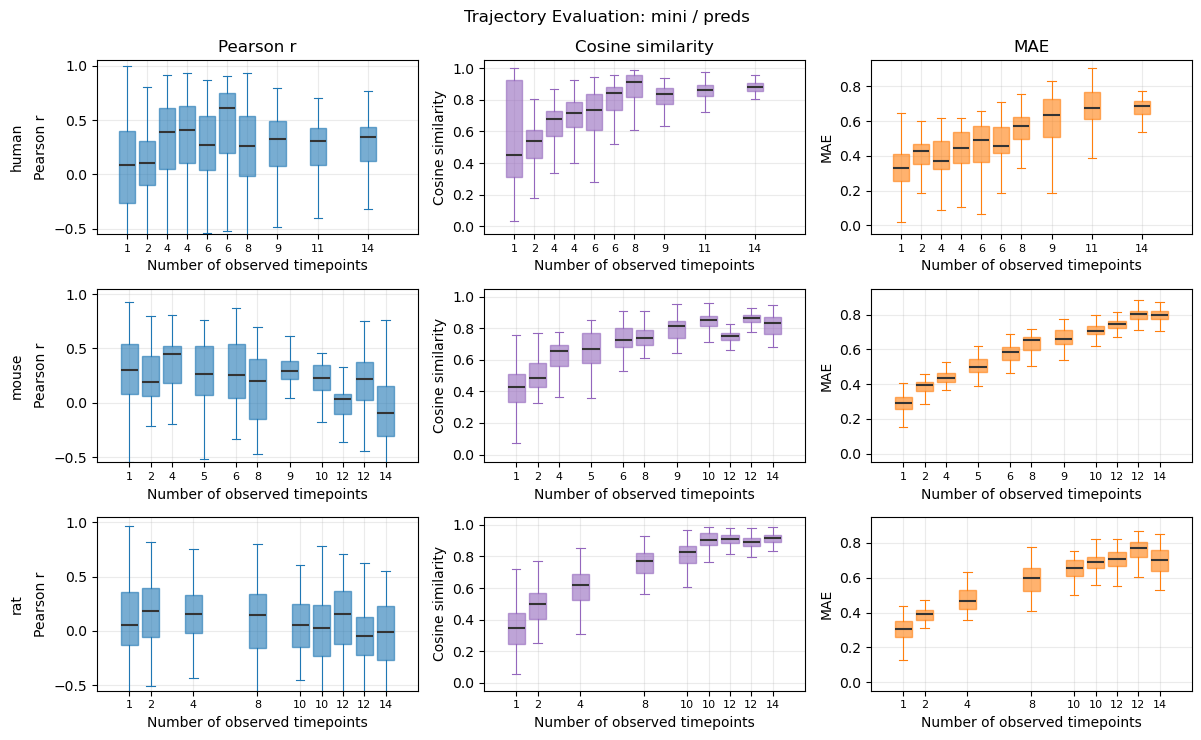

In [57]:
species_plot = sorted(site_corr_all["species"].dropna().unique())
metric_specs = [
    ("pearson_r", "Pearson r", "#1f77b4", (-0.55, 1.05)),
    ("cosine", "Cosine similarity", "#9467bd", (-0.05, 1.05)),
    ("mae", "MAE", "#ff7f0e", (-0.05, 0.95)),
]
n_bins = 20
fig, axes = plt.subplots(
    len(species_plot), len(metric_specs),
    figsize=(12, max(2.5 * len(species_plot), 3.0)),
    sharex=False,
    squeeze=False
)
for r, sp in enumerate(species_plot):
    sp_df = site_corr_all[site_corr_all["species"] == sp].copy()
    for c, (metric_key, metric_label, color, ylim) in enumerate(metric_specs):
        ax = axes[r, c]
        dfm = sp_df[np.isfinite(sp_df["n_obs_usage"]) & np.isfinite(sp_df[metric_key])].copy()

        if len(dfm) > 0 and dfm["n_obs_usage"].nunique() > 1:
            q = min(n_bins, dfm["n_obs_usage"].nunique())
            if q >= 2:
                dfm["n_obs_bin"] = pd.qcut(dfm["n_obs_usage"], q=q, duplicates="drop")

                # Use bin midpoint as numeric x position
                dfm["bin_mid"] = dfm["n_obs_bin"].apply(lambda b: (b.left + b.right) / 2)
                bin_order = sorted(dfm["bin_mid"].unique())

                box_data = [
                    dfm.loc[dfm["bin_mid"] == mid, metric_key].dropna().values
                    for mid in bin_order
                ]
                box_data = [v for v in box_data if len(v) > 0]
                positions = [mid for mid, v in zip(bin_order, box_data) if len(v) > 0]

                if box_data:
                    # Scale box width to ~80% of the smallest gap between positions
                    gaps = np.diff(sorted(positions))
                    width = 0.8 * gaps.min() if len(gaps) > 0 else 1.0

                    bp = ax.boxplot(
                        box_data,
                        positions=positions,
                        widths=width,
                        patch_artist=True,
                        showfliers=False,
                        manage_ticks=False
                    )
                    for patch in bp["boxes"]:
                        patch.set_facecolor(color)
                        patch.set_alpha(0.6)
                        patch.set_edgecolor(color)
                    for element in ["whiskers", "caps"]:
                        for artist in bp[element]:
                            artist.set_color(color)
                            artist.set_linewidth(0.8)
                    for median in bp["medians"]:
                        median.set_color("#333333")
                        median.set_linewidth(1.5)

                    x_min, x_max = dfm["n_obs_usage"].min(), dfm["n_obs_usage"].max()
                    pad = max(1.0, 0.02 * (x_max - x_min))
                    ax.set_xlim(x_min - pad, x_max + pad)

        ax.set_ylim(*ylim)
        ax.grid(alpha=0.25)
        ax.set_xlabel("Number of observed timepoints")
        # Integer x labels with step to avoid overcrowding
        step = max(1, len(positions) // 10)  # show ~10 labels max
        ax.set_xticks(positions)
        ax.set_xticklabels(
            [str(int(round(p))) if i % step == 0 else "" for i, p in enumerate(positions)], fontsize=8
        )
        ax.set_ylabel(metric_label)
        if r == 0:
            ax.set_title(metric_label)
        if c == 0:
            ax.text(
                -0.25, 0.5, sp,
                transform=ax.transAxes,
                rotation=90,
                va="center", ha="center", fontsize=10
            )

plt.suptitle(f"Trajectory Evaluation: {model} / {pd_key}", fontsize=12)
plt.tight_layout()
fig.savefig(
    os.path.join(work_dir, model, f"{pd_key}", "trajectory_correlation_vs_number_observed_sites.png"),
    dpi=300, bbox_inches="tight"
)

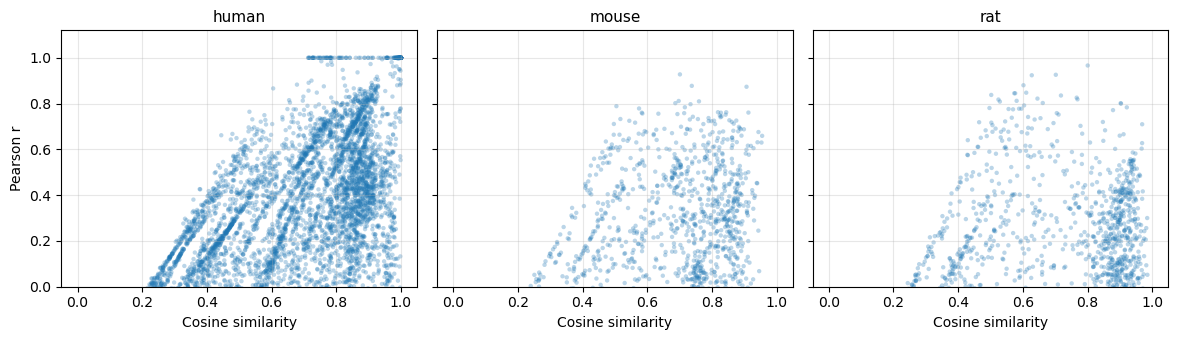

In [58]:
# Scatterplot of cosine similarity vs pearson correlation; one plot for every species

species_plot = sorted(site_corr_all["species"].dropna().unique())
n_species = len(species_plot)

fig, axes = plt.subplots(1, n_species, figsize=(n_species * 4, 3.5), sharey=True)

if n_species == 1:
    axes = [axes]

for ax, sp in zip(axes, species_plot):
    sp_data = site_corr_all[site_corr_all["species"] == sp].copy()
    
    # Filter for finite values
    sp_data_clean = sp_data[np.isfinite(sp_data["cosine"]) & np.isfinite(sp_data["pearson_r"])].copy()
    
    scatter = ax.scatter(
        sp_data_clean["cosine"],
        sp_data_clean["pearson_r"],
        s=10,
        alpha=0.3,
        color="#1f77b4",
        edgecolors="none"
    )
    
    ax.set_xlabel("Cosine similarity", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Pearson r", fontsize=10)
    ax.set_title(sp, fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.55, 1.05)

plt.tight_layout()
plt.show()
fig.savefig(
    os.path.join(work_dir, model, f"{pd_key}", "trajectory_cosine_vs_pearson.png"),
    dpi=300, bbox_inches="tight"
)

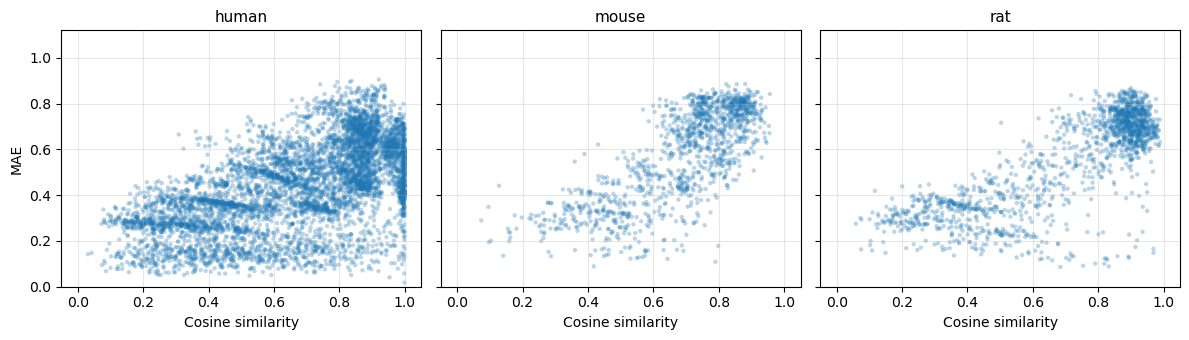

In [59]:
# Scatterplot of cosine similarity vs MAE; one plot for every species

species_plot = sorted(site_corr_all["species"].dropna().unique())
n_species = len(species_plot)

fig, axes = plt.subplots(1, n_species, figsize=(n_species * 4, 3.5), sharey=True)

if n_species == 1:
    axes = [axes]

for ax, sp in zip(axes, species_plot):
    sp_data = site_corr_all[site_corr_all["species"] == sp].copy()
    
    # Filter for finite values
    sp_data_clean = sp_data[np.isfinite(sp_data["cosine"]) & np.isfinite(sp_data["mae"])].copy()
    
    scatter = ax.scatter(
        sp_data_clean["cosine"],
        sp_data_clean["mae"],
        s=10,
        alpha=0.3,
        color="#1f77b4",
        edgecolors="none"
    )
    
    ax.set_xlabel("Cosine similarity", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("MAE", fontsize=10)
    ax.set_title(sp, fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 0.95)

plt.tight_layout()
plt.show()
fig.savefig(
    os.path.join(work_dir, model, f"{pd_key}", "trajectory_cosine_vs_mae.png"),
    dpi=300, bbox_inches="tight"
)

Correlation is low for the sites observed in small number of conditions.

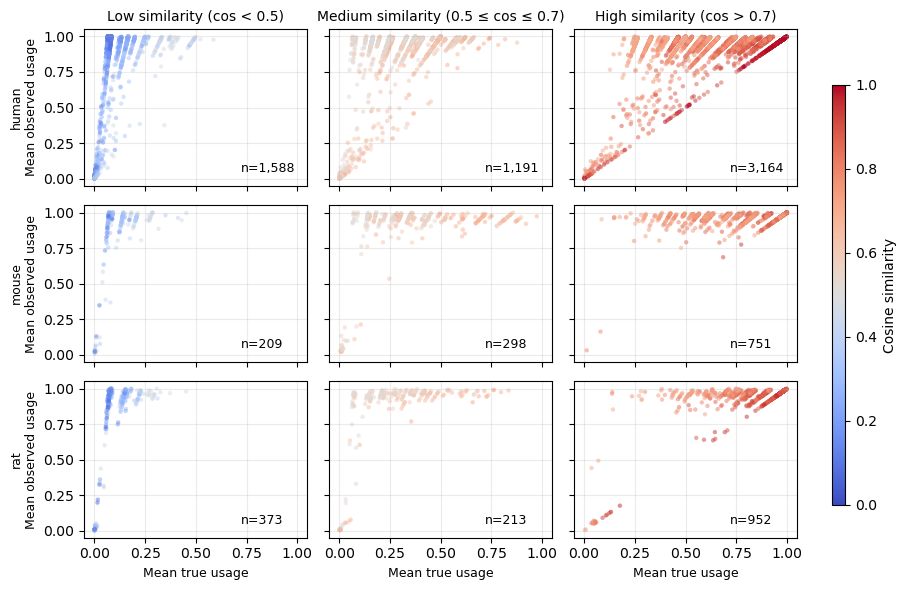

In [60]:
# Scatter: mean true usage vs mean observed usage
# rows = species, columns = cosine-similarity groups

species_plot = [s for s in SPECIES_ORDER if s in site_corr_all["species"].unique()]
cos_capped = site_corr_all["cosine"].clip(0, 1)

groups = [
    ("Low similarity (cos < 0.5)", lambda c: c < 0.5),
    ("Medium similarity (0.5 ≤ cos ≤ 0.7)", lambda c: (c >= 0.5) & (c <= 0.7)),
    ("High similarity (cos > 0.7)", lambda c: c > 0.7),
]

n_rows = len(species_plot)
n_cols = len(groups)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, max(2 * n_rows, 3.2)),
    sharex=True, sharey=True,
    squeeze=False
)

norm = plt.Normalize(vmin=0.0, vmax=1.0)
cmap = "coolwarm"

for r, sp in enumerate(species_plot):
    sp_data = site_corr_all[site_corr_all["species"] == sp]
    sp_cos = sp_data["cosine"].clip(0, 1)

    for c, (label, mask_fn) in enumerate(groups):
        ax = axes[r, c]
        mask = mask_fn(sp_cos)
        subset = sp_data.loc[mask]
        cvals = sp_cos.loc[mask]

        ax.scatter(
            subset["mean_true_usage"],
            subset["mean_obs_usage"],
            c=cvals,
            cmap=cmap,
            norm=norm,
            s=10,
            alpha=0.5,
            edgecolors="none"
        )

        if r == 0:
            ax.set_title(label, fontsize=10)
        if c == 0:
            ax.set_ylabel(f"{sp}\nMean observed usage", fontsize=9)
        else:
            ax.set_ylabel("")

        if r == n_rows - 1:
            ax.set_xlabel("Mean true usage", fontsize=9)

        ax.text(
            0.7, 0.15, f"n={mask.sum():,}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9
        )
        ax.grid(alpha=0.25)

# Leave room on the right for the colorbar
fig.tight_layout(rect=[0, 0, 0.90, 1])

# Add a dedicated colorbar axis outside the plot grid
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Cosine similarity")

# Save
fig.savefig(
    os.path.join(work_dir, model, f"{pd_key}", "trajectory_mean_usage_scatter_by_cosine_group.png"),
    dpi=300, bbox_inches="tight"
)

Correlation is low for the sites along the y-axis because they are observed (measured) in small number of conditions.

#### Splice site examples

Function to plot splice site trajectories for selected sites

In [61]:
def plot_splice_site_dynamics(
    df_all,
    site_coords,
    data_config,
    tissue_order=None,
    tissue_colors=None,
    figsize=None,
    title=None,
    verbose=False,
):
    """
    Plot splice site dynamics with one tissue per subplot for a single site.
    Displays both true (solid line) and predicted (dotted line) usage.
    
    Args:
        df_all: DataFrame with splice site data (Species, Chromosome, Position, Strand, condition columns, Alpha, Beta, SSE)
        site_coords: Site coordinate string. Format: "species chrom:pos[:strand]" (e.g., "mouse 1:15188:+")
                     Strand is optional; if not specified, all strands included.
        data_config: Config dict with condition_labels mapping for each species
        tissue_order: List of tissues in desired order
        tissue_colors: Dict mapping tissue names to colors
        figsize: Tuple of (width, height) or None for auto
        title: Figure title (auto-generated if None)
        verbose: If True, print condition information
        
    Returns:
        matplotlib Figure object
    """
    from matplotlib.ticker import MaxNLocator
    
    # Parse site coordinates
    parts = site_coords.strip().split()
    if len(parts) != 2:
        raise ValueError(f"Invalid coordinate format '{site_coords}'. Expected 'species chrom:pos[:strand]'")
    
    species = parts[0].lower()
    chrom_pos_strand = parts[1].split(':')
    
    if len(chrom_pos_strand) < 2 or len(chrom_pos_strand) > 3:
        raise ValueError(f"Invalid chrom:pos[:strand] format in '{site_coords}'")
    
    chrom = chrom_pos_strand[0]
    try:
        pos = int(chrom_pos_strand[1])
    except ValueError:
        raise ValueError(f"Invalid position in '{site_coords}'")
    
    # Filter to this site
    mask = (df_all['species'] == species) & (df_all['chromosome'] == str(chrom)) & (df_all['position'] == pos)
    df_site = df_all[mask].copy()
    
    if df_site.empty:
        raise ValueError(f"No data found for {species} {chrom}:{pos}")
    
    # Find condition column
    cond_col = next((c for c in df_site.columns if "cond" in c.lower()), None)
    if cond_col is None:
        raise ValueError(f"No condition column found for {species} {chrom}:{pos}")
    
    # Set defaults
    if tissue_order is None:
        tissue_order = TISSUE_ORDER
    if tissue_colors is None:
        tissue_colors = TISSUE_COLORS
    
    # Map conditions to tissues and timepoints
    tissue_list = []
    timepoint_list = []
    
    for idx, row in df_site.iterrows():
        cond_idx = row[cond_col]
        cond_labels = data_config.get(species, {})
        idx_to_name = {v: k for k, v in cond_labels.items()}
        cond_name = idx_to_name.get(int(cond_idx), None)
        
        if cond_name:
            tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
            try:
                tp = int(cond_name.rsplit('_', 1)[1])
            except (IndexError, ValueError):
                tp = None
            tissue_list.append(tissue)
            timepoint_list.append(tp)
        else:
            tissue_list.append(None)
            timepoint_list.append(None)
    
    df_site['tissue'] = tissue_list
    df_site['timepoint'] = timepoint_list
    df_site = df_site.dropna(subset=['tissue', 'timepoint'])
    df_site['timepoint'] = df_site['timepoint'].astype(int)
    
    # Get tissues present and all timepoints
    tissues = tissue_order #[t for t in tissue_order if t in df_site['tissue'].values]
    all_tps = sorted(df_site['timepoint'].unique())
    
    if not tissues:
        raise ValueError(f"No valid tissue-timepoint combinations found for {species} {chrom}:{pos}")
    
    if verbose:
        print(f"\n{species} {chrom}:{pos}")
        print(f"  Total data points: {len(df_site)}")
        print(f"  Tissues present: {', '.join(tissues)}")
        print(f"  Timepoints: {', '.join(map(str, all_tps))}")
    
    # Create subplots: one per tissue
    n_tissues = len(tissues)
    n_cols = min(3, n_tissues)
    n_rows = (n_tissues + n_cols - 1) // n_cols
    
    if figsize is None:
        figsize = (n_cols * 5, n_rows * 4)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    # Plot each tissue
    for tissue_idx, tissue in enumerate(tissues):
        ax = axes[tissue_idx]
        
        tissue_data = df_site[df_site['tissue'] == tissue]
        color = tissue_colors.get(tissue, '#808080')
            
        if tissue_data.empty:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                        ha='center', va='center', fontsize=11, color='lightgrey')
                ax.grid(axis='y', alpha=0.3, linestyle='--')
                ax.set_xlim(all_tps[0] - 0.5, all_tps[-1] + 0.5)
                ax.set_ylim(-0.05, 1.05)
                ax.set_xlabel('Timepoint', fontsize=10)
                ax.set_ylabel('Usage', fontsize=10)
                ax.set_title(f'{tissue}', fontsize=11)
                continue

        # Plot both true and predicted usage
        for metric_type, linestyle, marker, label in [
            ('true_usage', '-', 'o', 'True'),
            ('pred_usage', '--', 'x', 'Predicted')
        ]:
            grouped = tissue_data.groupby('timepoint')[metric_type].agg(['mean', 'std', 'count']).reset_index()
            grouped['std'] = grouped['std'].fillna(0)
            
            x_coords = grouped['timepoint']
            
            # Plot shaded area for variance (semi-transparent)
            ax.fill_between(
                x_coords,
                grouped['mean'] - grouped['std'],
                grouped['mean'] + grouped['std'],
                color=color,
                alpha=0.12,
                linewidth=0
            )
            
            # Plot line and markers
            ax.plot(x_coords, grouped['mean'], 
                    color=color, linewidth=1.5, 
                    linestyle=linestyle,
                    marker=marker, markersize=4,
                    alpha=0.7, zorder=2, label=label)
        
        # Formatting
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xlim(all_tps[0] - 0.5, all_tps[-1] + 0.5)
        ax.set_ylim(-0.05, 1.05)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        ax.set_xlabel('Timepoint', fontsize=10)
        ax.set_ylabel('Usage', fontsize=10)
        ax.set_title(f'{tissue}', fontsize=11)
        #ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Hide unused subplots
    for idx in range(n_tissues, len(axes)):
        axes[idx].set_visible(False)
        
    # Create a single legend for the entire figure
    handles = [
        plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='-', marker='o', markersize=4, label='True'),
        plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', marker='x', markersize=4, label='Predicted')
    ]
    fig.legend(handles=handles, loc='upper right', fontsize=10, framealpha=0.9)

    # Overall title
    if title is None:
        title = f'{species} {chrom}:{pos}'
    fig.suptitle(title, fontsize=14, y=0.995)
    
    plt.tight_layout()
    
    return fig

 Extract condition mapping from the data configcond_config = {}

In [62]:
cond_config = {}
for sp in usage_results:
    sp_data = usage_results[sp]
    keys = sp_data['idx_to_label'].values()
    vals = sp_data['idx_to_label'].keys()
    cond_config[sp] = dict(zip(keys, vals))


Combine per-site predictions and per-tissue correlations

In [63]:
# Combine summary stats and original data for sll species
site_usage_df_corr = usage_df_all.merge(
    site_corr_all,
    on=["species", "tissue", "chr_pos"],
    how="left"
)

# Replace NaN in mean_true_usage with 0
site_usage_df_corr["mean_true_usage"] = site_usage_df_corr["mean_true_usage"].fillna(0)

# Split chr_pos -> chromosome, position
site_usage_df_corr[["chromosome", "position"]] = site_usage_df_corr["chr_pos"].str.split(":", expand=True)
site_usage_df_corr["position"] = site_usage_df_corr["position"].astype(int)

# Reorder columns: species, chromosome, position, then the rest
cols = ["species", "chromosome", "position"] + [c for c in site_usage_df_corr.columns if c not in ["species", "chromosome", "position"]]
site_usage_df_corr = site_usage_df_corr[cols]

site_usage_df_corr

,species,chromosome,position,chr_pos,true_usage,pred_usage,cond_idx,tissue,timepoint,pearson_r,mae,cosine,n_obs_usage,mean_obs_usage,mean_true_usage,mean_pred_usage,min_obs_usage,min_true_usage,max_obs_usage
0,human,1,1535506,1:1535506,0.0,0.217427,0,Brain,1,0.054729,0.479383,0.543801,5.0,0.942000,0.314000,0.136056,0.922,0.314000,0.973
1,human,1,1535588,1:1535588,0.0,0.189056,0,Brain,1,-0.029488,0.461180,0.473466,4.0,0.985000,0.262667,0.123305,0.949,0.262667,1.000
2,human,1,1535796,1:1535796,0.0,0.194543,0,Brain,1,-0.077970,0.654323,0.649884,9.0,0.954222,0.572533,0.126649,0.910,0.572533,0.992
3,human,1,1539683,1:1539683,0.0,0.215289,0,Brain,1,-0.371905,0.661365,0.595328,10.0,0.918200,0.612133,0.151037,0.846,0.612133,0.990
4,human,1,1539789,1:1539789,0.0,0.232782,0,Brain,1,0.275755,0.318875,0.510233,3.0,0.821333,0.164267,0.124982,0.783,0.164267,0.850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183692,rat,1,75675786,1:75675786,0.0,0.342076,89,Testis,9,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
183693,rat,1,75675879,1:75675879,0.0,0.453610,89,Testis,9,-0.022007,0.370888,0.346837,2.0,0.927500,0.142692,0.245391,0.874,0.142692,0.981
183694,rat,1,75676463,1:75676463,0.0,0.325824,89,Testis,9,0.243598,0.317205,0.449307,2.0,0.892000,0.137231,0.187618,0.829,0.137231,0.955
183695,rat,1,75676605,1:75676605,0.0,0.364323,89,Testis,9,0.171759,0.339628,0.418994,2.0,0.912500,0.140385,0.215987,0.912,0.140385,0.913


#### Select top-correlated sites

Sort the data by top correlation

In [64]:
metric = "mae"
# Calculate median cor per site (across tissues) for sorting
site_corr_all[f'median_{metric}'] = site_corr_all.groupby(['species', 'chr_pos'])[metric].transform('median')
# Sort sites by species and median correlation metric 
asc = True if metric in ["mae"] else False  # ascending for error metrics, descending for correlation metrics
sorted_sites = site_corr_all[['species', 'chr_pos', f'median_{metric}']].drop_duplicates().sort_values(['species', f'median_{metric}'], ascending=[True, asc]).reset_index(drop=True)
# Create id column for categories
sorted_sites['site_id'] = sorted_sites['species'] + "_" + sorted_sites['chr_pos']

In [65]:
# How many site have high median correlation (e.g. median_pearson_r > 0.5)?
if metric.startswith("mae"):
    threshold = 0.4
    top_sites = sorted_sites[sorted_sites[f'median_{metric}'] < threshold]
    print(f"Number of sites with median {metric} < {threshold}: {len(top_sites)} / {len(sorted_sites)} ({len(top_sites) / len(sorted_sites):.2%})")
else:
    threshold = 0.6
    top_sites = sorted_sites[sorted_sites[f'median_{metric}'] > threshold]
    print(f"Number of sites with median {metric} > {threshold}: {len(top_sites)} / {len(sorted_sites)} ({len(top_sites) / len(sorted_sites):.2%})")

Number of sites with median mae < 0.4: 839 / 1911 (43.90%)


In [66]:
# Order site_usage_df_corr by this sorted order of sites
site_usage_df_corr['site_id'] = site_usage_df_corr['species'] + "_" + site_usage_df_corr['chr_pos']
site_usage_df_corr['site_id'] = site_usage_df_corr['site_id'].astype(str)
site_usage_df_corr['site_id'] = pd.Categorical(site_usage_df_corr['site_id'], categories=sorted_sites['site_id'], ordered=True)
site_usage_df_corr = site_usage_df_corr.sort_values('site_id').reset_index(drop=True)

In [67]:
# How many sites cdidn't have correlation metrics and thus have NaN site_id after merging?
print(f"Removing {site_usage_df_corr['site_id'].isna().sum()} rows corresponding to {site_usage_df_corr[site_usage_df_corr['site_id'].isna()][['species', 'chr_pos']].drop_duplicates().shape[0]} sites with missing site_id after merging.")
site_usage_df_corr = site_usage_df_corr[~site_usage_df_corr['site_id'].isna()].copy().reset_index(drop=True)

Removing 264 rows corresponding to 2 sites with missing site_id after merging.


In [68]:
# How many sites have NaN correlation (because all true values are 0)?
print(f"Number of sites with NaN correlation: {site_usage_df_corr['pearson_r'].isna().sum()} / {len(site_usage_df_corr)} ({site_usage_df_corr['pearson_r'].isna().mean():.2%})")

Number of sites with NaN correlation: 72853 / 183433 (39.72%)


Select top examples to plot

In [69]:
df = site_usage_df_corr[
    (site_usage_df_corr["site_id"].isin(top_sites['site_id']))
    & (site_usage_df_corr["n_obs_usage"] > 5)
]
df

examples_top = df[['species', 'chr_pos']].drop_duplicates().head(10)
example_coords = [f"{row['species']} {row['chr_pos']}" for _, row in examples_top.iterrows()]
print(f"Top {len(example_coords)} examples:", example_coords)

Top 10 examples: ['human 1:18881418', 'human 1:18871789', 'human 1:18882671', 'human 1:18881492', 'human 1:12600360', 'human 1:11790715', 'human 1:21610268', 'human 1:11790747', 'human 1:21851589', 'human 1:18872803']


In [70]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = os.path.join(work_dir, model, pd_key, f"splice_sites_trajectory_top_{metric}.pdf")

with PdfPages(pdf_path) as pdf:
    for coords in example_coords:
        fig = plot_splice_site_dynamics(
            df_all=site_usage_df_corr[site_usage_df_corr['true_usage'] > 0],
            site_coords=coords,
            data_config=cond_config,
            tissue_order=TISSUE_ORDER,
            tissue_colors=TISSUE_COLORS,
            figsize=(8, 6),
            verbose=False
        )
        if fig is not None:
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)  # free memory after saving each page

#### Select tissue-specific sites

In [71]:
# Identify sites that are low in all tissues (mean_true_usage < 0.1) except selected tissues where they are high (mean_true_usage > 0.5)
# and check if these sites have higher correlation in the selected tissues

# Define thresholds
low_threshold = 0.2
high_threshold = 0.7

# Define selected tissues for each species
selected_tissues_by_species = {
    "human": ["Brain", "Cerebellum", "Midbrain"],
    "mouse": ["Brain", "Cerebellum"],
    "rat": ["Brain", "Cerebellum"],
    "rabbit": ["Brain", "Cerebellum"],
    "opossum": ["Brain", "Cerebellum"],
}
specific_sites = {}
for sp, tissues in selected_tissues_by_species.items():
    
    sp_data = site_usage_df_corr[site_usage_df_corr["species"] == sp]

    # Identify sites that are high in selected tissues
    tissue_data = sp_data[sp_data["tissue"].isin(tissues)]

    # Identify sites that are low in all tissues except selected ones
    other_tissues = [t for t in sp_data["tissue"].unique() if t not in tissues]
    other_data = sp_data[sp_data["tissue"].isin(other_tissues)]

    # Select sites that are low in other tissues and high in selected tissues
    low_in_others = other_data.groupby("chr_pos")["mean_true_usage"].max() < low_threshold
    print(f"{sp} - {tissues}: {low_in_others.sum()} sites that are low in other tissues")
    high_in_this = tissue_data.groupby("chr_pos")["mean_true_usage"].min() > high_threshold
    print(f"{sp} - {tissues}: {high_in_this.sum()} sites that are high in selected tissues")

    selected_low_sites = low_in_others.index[low_in_others]
    selected_high_sites = high_in_this.index[high_in_this]
    selected_sites = set(selected_low_sites) & set(selected_high_sites)
    print(f"{sp} - {tissues}: {len(selected_sites)} sites that are low in other tissues and high in selected tissues")

    # Check correlation for these sites in the selected tissue vs others
    corr_selected = tissue_data[tissue_data["chr_pos"].isin(selected_sites)]["pearson_r"].dropna()
    corr_others = other_data[other_data["chr_pos"].isin(selected_sites)]["pearson_r"].dropna()

    specific_sites[sp] = {
        "tissue": tissue,
        "n_selected_sites": len(selected_sites),
        "selected_sites": selected_sites,
    }

human - ['Brain', 'Cerebellum', 'Midbrain']: 472 sites that are low in other tissues
human - ['Brain', 'Cerebellum', 'Midbrain']: 185 sites that are high in selected tissues
human - ['Brain', 'Cerebellum', 'Midbrain']: 1 sites that are low in other tissues and high in selected tissues
mouse - ['Brain', 'Cerebellum']: 127 sites that are low in other tissues
mouse - ['Brain', 'Cerebellum']: 18 sites that are high in selected tissues
mouse - ['Brain', 'Cerebellum']: 2 sites that are low in other tissues and high in selected tissues
rat - ['Brain', 'Cerebellum']: 218 sites that are low in other tissues
rat - ['Brain', 'Cerebellum']: 117 sites that are high in selected tissues
rat - ['Brain', 'Cerebellum']: 11 sites that are low in other tissues and high in selected tissues
rabbit - ['Brain', 'Cerebellum']: 0 sites that are low in other tissues
rabbit - ['Brain', 'Cerebellum']: 0 sites that are high in selected tissues
rabbit - ['Brain', 'Cerebellum']: 0 sites that are low in other tissues 

In [72]:
# extract all sites from dictionary with structure e.g.
all_specific_sites = set()
for sp, info in specific_sites.items():
    all_specific_sites.update({f"{sp}_{site}" for site in info["selected_sites"]})
print(f"All specific sites: {len(all_specific_sites)}", all_specific_sites)

All specific sites: 14 {'rat_1:32548773', 'rat_1:32498853', 'human_1:10326110', 'rat_1:32497678', 'rat_1:32549462', 'rat_1:32546750', 'rat_1:48420028', 'rat_1:48399615', 'mouse_1:25068355', 'rat_1:48396977', 'rat_1:32510122', 'rat_1:32496185', 'mouse_1:25074684', 'rat_1:32510051'}


Select top examples to plot

In [73]:
site_usage_df_corr

,species,chromosome,position,chr_pos,true_usage,pred_usage,cond_idx,tissue,timepoint,pearson_r,mae,cosine,n_obs_usage,mean_obs_usage,mean_true_usage,mean_pred_usage,min_obs_usage,min_true_usage,max_obs_usage,site_id
0,human,1,9071672,1:9071672,0.000,0.126027,72,Ovary,9,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,human_1:9071672
1,human,1,9071672,1:9071672,0.000,0.058210,62,Liver,9,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,human_1:9071672
2,human,1,9071672,1:9071672,0.000,0.048497,10,Brain,5,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,human_1:9071672
3,human,1,9071672,1:9071672,0.000,0.058922,17,Cerebellum,13,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,human_1:9071672
4,human,1,9071672,1:9071672,0.000,0.019290,76,Testis,12,0.000883,0.065853,0.407051,3.0,0.053333,0.010667,0.066642,0.044,0.010667,0.068,human_1:9071672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183428,rat,1,51192357,1:51192357,0.000,0.217045,7,Brain,3,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,rat_1:51192357
183429,rat,1,51192357,1:51192357,0.992,0.054075,60,Liver,6,0.146630,0.856516,0.872968,13.0,0.990615,0.990615,0.137521,0.983,0.990615,0.997,rat_1:51192357
183430,rat,1,51192357,1:51192357,0.989,0.054841,53,Liver,12,0.146630,0.856516,0.872968,13.0,0.990615,0.990615,0.137521,0.983,0.990615,0.997,rat_1:51192357
183431,rat,1,51192357,1:51192357,0.000,0.147043,35,Heart,5,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,rat_1:51192357


In [74]:
df = site_usage_df_corr[
    (site_usage_df_corr["site_id"].isin(all_specific_sites))
    & (site_usage_df_corr["mae"] < 0.4)
    & (site_usage_df_corr["n_obs_usage"] > 6)
]
df = df.sort_values(['pearson_r'], ascending=False)

examples_top = df['site_id'].drop_duplicates().head(10)
example_coords = [site.replace("_", " ") for site in examples_top]
print(f"Top {len(example_coords)} examples:", example_coords)

Top 1 examples: ['human 1:10326110']


In [75]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = os.path.join(work_dir, model, pd_key, "splice_sites_trajectory_tissue_specific.pdf")

with PdfPages(pdf_path) as pdf:
    for coords in example_coords:
        try:
            fig = plot_splice_site_dynamics(
                df_all=site_usage_df_corr, #[site_usage_df_corr['true_usage'] > 0],
                site_coords=coords,
                data_config=cond_config,
                tissue_order=TISSUE_ORDER,
                tissue_colors=TISSUE_COLORS,
                figsize=(8, 6),
                verbose=False
            )
            if fig is not None:
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)  # free memory after saving each page
        except Exception as e:
            print(f"Error plotting {coords}: {e}")